In [19]:
import pandas as pd
import numpy as np
import time

# Xử lý dữ liệu & Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Feature Selection
from sklearn.feature_selection import SelectKBest, mutual_info_regression, SelectFromModel

# Mô hình
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
try:
    df_train = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Vui lòng tải file train.csv từ Kaggle và đặt vào cùng thư mục.")
X = df_train.drop(['Id', 'SalePrice'], axis=1)
y = np.log1p(df_train['SalePrice'])

In [20]:
print("--- 1. Xem 5 dòng đầu tiên ---")
display(df_train.head())

print("\n--- 2. Thông tin kiểu dữ liệu ---")
df_train.info()

print("\n--- 3. Thống kê mô tả dữ liệu số ---")
display(df_train.describe())

print("\n--- 4. Tỉ lệ dữ liệu bị thiếu (Top 10 cột) ---")
missing_data = df_train.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percent = (missing_data / len(df_train)) * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing_data, 'Tỷ lệ (%)': missing_percent})
display(missing_df.head(10))

--- 1. Xem 5 dòng đầu tiên ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- 2. Thông tin kiểu dữ liệu ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



--- 4. Tỉ lệ dữ liệu bị thiếu (Top 10 cột) ---


,Số lượng thiếu,Tỷ lệ (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


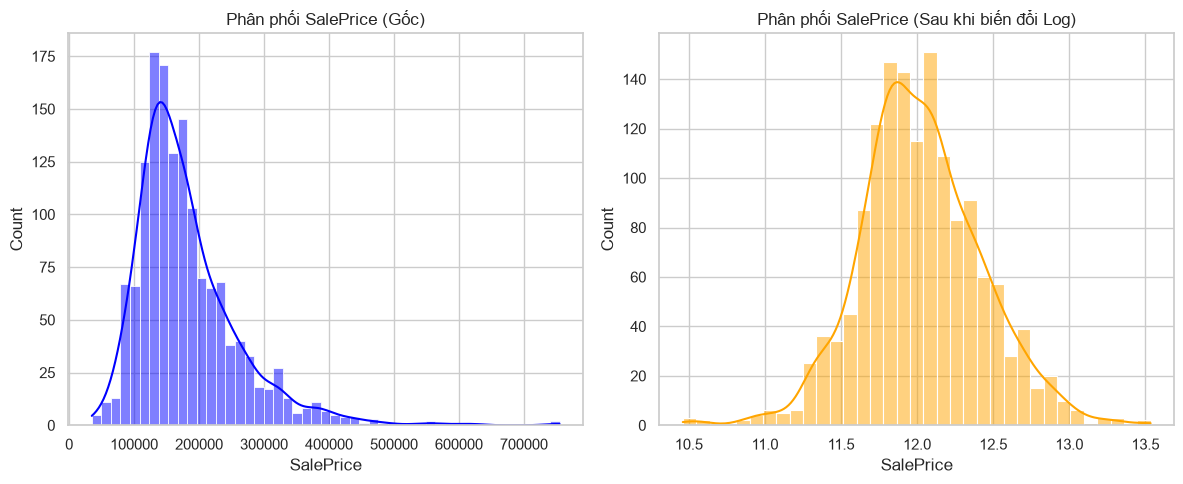

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title('Phân phối SalePrice (Gốc)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_train['SalePrice']), kde=True, color='orange')
plt.title('Phân phối SalePrice (Sau khi biến đổi Log)')
plt.tight_layout()
plt.show()

In [22]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [23]:
feature_selectors = {
    'All_Features': 'passthrough',
    'SelectKBest_MutualInfo': SelectKBest(score_func=mutual_info_regression, k=80),
    'SelectFromModel_RF': SelectFromModel(RandomForestRegressor(n_estimators=50, random_state=42), max_features=80)
}

models = {
    'SVR': SVR(C=10, epsilon=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
}

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

print(f"{'Selector':<25} | {'Model':<15} | {'RMSE Mean':<10} | {'Time (s)'}")
print("-" * 70)

for selector_name, selector in feature_selectors.items():
    for model_name, model in models.items():
        start_time = time.time()
        
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('feature_selection', selector),
            ('regressor', model)
        ])
        
    
        cv_scores = cross_val_score(clf, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
        
    
        rmse_scores = np.sqrt(-cv_scores)
        mean_rmse = rmse_scores.mean()
        
        elapsed_time = time.time() - start_time
        
        results.append({
            'Feature_Selection': selector_name,
            'Model': model_name,
            'RMSE': mean_rmse,
            'Time': elapsed_time
        })
        
        print(f"{selector_name:<25} | {model_name:<15} | {mean_rmse:.5f}    | {elapsed_time:.2f}s")
results_df = pd.DataFrame(results)

Selector                  | Model           | RMSE Mean  | Time (s)
----------------------------------------------------------------------
All_Features              | SVR             | 0.14681    | 0.77s
All_Features              | RandomForest    | 0.14559    | 5.80s
All_Features              | XGBoost         | 0.14350    | 1.27s
SelectKBest_MutualInfo    | SVR             | 0.14655    | 5.59s
SelectKBest_MutualInfo    | RandomForest    | 0.14594    | 8.59s
SelectKBest_MutualInfo    | XGBoost         | 0.14506    | 6.02s
SelectFromModel_RF        | SVR             | 0.15281    | 3.39s
SelectFromModel_RF        | RandomForest    | 0.14785    | 5.01s
SelectFromModel_RF        | XGBoost         | 0.14779    | 3.78s


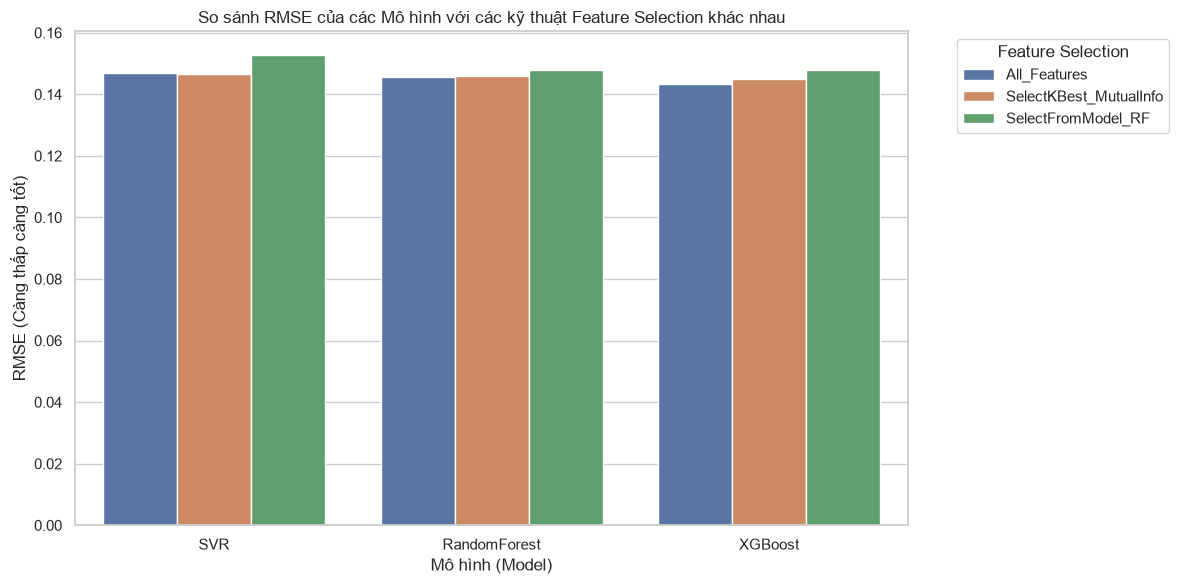

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Feature_Selection')
plt.title('So sánh RMSE của các Mô hình với các kỹ thuật Feature Selection khác nhau')
plt.ylabel('RMSE (Càng thấp càng tốt)')
plt.xlabel('Mô hình (Model)')
plt.legend(title='Feature Selection', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()